
# Tier 2 — Sunda-Asri Basin Deep-Dive: Full Screening Workflow

**Status: PROTOTYPE.** This notebook replicates the full de Jonge-Anderson
et al. (2025) [MB] workflow — depth/temperature/pressure grid → CO2
thermophysical properties (CoolProp) → triple cut-off (porosity, CO2
density, fault distance) → DBSCAN clustering with minimum-area filter →
Monte Carlo volumetric capacity — applied to the Sunda-Asri Basin.

**Data fallback behaviour (important):** this notebook checks for real data
(GEBCO/GlobSed NetCDF grids, digitized basin boundary) in `data/raw/` and
`data/processed/` first. If any are missing, it falls back to an
**illustrative synthetic grid** instead of crashing — the active data
source is always printed explicitly in Section 1 so there is never any
ambiguity about what produced a given result. See `docs/methodology.md`
and `docs/data_provenance.md` for how to plug in real data.


## 0. Setup

In [1]:

import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

_p = Path.cwd()
while not (_p / "config.yaml").exists() and _p != _p.parent:
    _p = _p.parent
REPO_ROOT = _p
sys.path.insert(0, str(REPO_ROOT / "src"))

from load_config import load_config
from co2_thermophysics import temperature_from_depth, pressure_from_depth, co2_density_kgm3, co2_phase
from optimal_zone_screening import distance_to_nearest_fault_km
from montecarlo_capacity import monte_carlo_capacity, summarize_capacity, NormalParam

cfg = load_config(REPO_ROOT / "config.yaml")
print("Repo root:", REPO_ROOT)
print("Target basin:", cfg["project"]["tier2_target_basin"])
print("Target SRL:", cfg["storage_readiness"]["tier2_target_srl"])


Repo root: c:\Users\Arsy Nuur\ccs-screening
Target basin: Sunda-Asri Basin (offshore West Java)
Target SRL: 2


## 1. Load basin boundary, fault traces & depth surface

Priority order (same philosophy as the Tier 1 notebook — always try real
data first, always print which source ended up being used):

1. **Boundary**: `data/processed/sunda_asri_boundary_digitized.csv` (QGIS
   digitization) → fallback `data/external/sunda_asri_boundary_illustrative.csv`
2. **Faults**: `data/processed/sunda_asri_faults_digitized.csv` → fallback
   `data/external/sunda_asri_faults_illustrative.csv`
3. **Depth surface**: GEBCO + GlobSed NetCDF grids in `data/raw/` (real
   bathymetry + sediment thickness) → fallback: synthetic bowl-shaped depth
   surface (deepens toward the basin centroid), clearly labelled illustrative.


In [2]:
import pandas as pd
import subprocess
import sys

def _ensure_sample_data():
    boundary_sample = REPO_ROOT / cfg["paths"]["sample"]["sunda_asri_boundary"]
    if not boundary_sample.exists():
        subprocess.run([sys.executable, str(REPO_ROOT / "src" / "fetch_open_data.py"), "--mode", "sample"], check=True)

_ensure_sample_data()

boundary_real_path = REPO_ROOT / cfg["paths"]["real"]["sunda_asri_boundary"]
boundary_sample_path = REPO_ROOT / cfg["paths"]["sample"]["sunda_asri_boundary"]
boundary_path = boundary_real_path if boundary_real_path.exists() else boundary_sample_path
boundary_source = "REAL (QGIS digitized)" if boundary_real_path.exists() else "ILLUSTRATIVE (hand-drawn placeholder)"

faults_real_path = REPO_ROOT / cfg["paths"]["real"]["sunda_asri_faults"]
faults_sample_path = REPO_ROOT / cfg["paths"]["sample"]["sunda_asri_faults"]
faults_path = faults_real_path if faults_real_path.exists() else faults_sample_path
faults_source = "REAL (QGIS digitized)" if faults_real_path.exists() else "ILLUSTRATIVE (hand-drawn placeholder)"

df_boundary = pd.read_csv(boundary_path)
df_faults = pd.read_csv(faults_path)

# Rename 'id' to 'fault_id' if present to maintain compatibility with downstream code
if "id" in df_faults.columns and "fault_id" not in df_faults.columns:
    df_faults = df_faults.rename(columns={"id": "fault_id"})

print(f"{'='*65}\nBOUNDARY SOURCE : {boundary_source}\nFAULTS SOURCE   : {faults_source}\n{'='*65}")
print(f"{len(df_boundary)} boundary vertices, {len(df_faults)} fault trace points "
      f"({df_faults['fault_id'].nunique()} distinct faults)")

BOUNDARY SOURCE : REAL (QGIS digitized)
FAULTS SOURCE   : REAL (QGIS digitized)
110 boundary vertices, 59 fault trace points (10 distinct faults)


### 1a. Depth surface — real GEBCO+GlobSed if available, else synthetic

DEPTH SURFACE SOURCE: REAL (GEBCO bathymetry + GlobSed sediment thickness)
Depth range inside basin: 895 - 1057 m


C:\Users\Arsy Nuur\AppData\Local\Temp\ipykernel_27092\3450548582.py:65: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


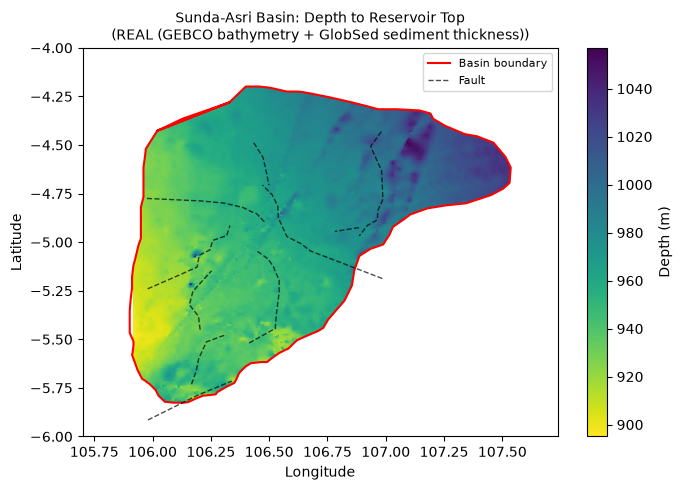

In [3]:

from matplotlib.path import Path as MPath

lat_min, lat_max = df_boundary["lat"].min() - 0.2, df_boundary["lat"].max() + 0.2
lon_min, lon_max = df_boundary["lon"].min() - 0.2, df_boundary["lon"].max() + 0.2

gebco_path = REPO_ROOT / cfg["paths"]["real"]["grid_gebco"]
globsed_path = REPO_ROOT / cfg["paths"]["real"]["grid_globsed"]

depth_source = None
if gebco_path.exists() and globsed_path.exists():
    try:
        import xarray as xr

        ds_gebco = xr.open_dataset(gebco_path)
        ds_globsed = xr.open_dataset(globsed_path)
        lat_name = "lat" if "lat" in ds_gebco.dims else "latitude"
        lon_name = "lon" if "lon" in ds_gebco.dims else "longitude"

        regional_gebco = ds_gebco.sel({lat_name: slice(lat_min, lat_max), lon_name: slice(lon_min, lon_max)}).load()
        regional_globsed = ds_globsed.interp(
            {lat_name: regional_gebco[lat_name], lon_name: regional_gebco[lon_name]}, method="linear"
        )

        grid_lon = regional_gebco[lon_name].values
        grid_lat = regional_gebco[lat_name].values
        lon_mesh, lat_mesh = np.meshgrid(grid_lon, grid_lat)
        depth_m = np.abs(regional_gebco["elevation"].values) + regional_globsed["z"].values
        depth_source = "REAL (GEBCO bathymetry + GlobSed sediment thickness)"
    except Exception as exc:
        print(f"[i] Found GEBCO/GlobSed files but failed to process them ({exc}); falling back to synthetic grid.")

if depth_source is None:
    # Synthetic bowl-shaped depth surface: shallow at the basin margins, deep
    # near the centroid, within a plausible range for a Cenozoic rift basin
    # (loosely following the depth ranges reported for Malay Basin aquifers
    # in [MB] Fig. 7 — NOT a real Sunda-Asri depth structure map).
    grid_lon = np.linspace(lon_min, lon_max, 60)
    grid_lat = np.linspace(lat_min, lat_max, 60)
    lon_mesh, lat_mesh = np.meshgrid(grid_lon, grid_lat)

    centroid_lon, centroid_lat = df_boundary["lon"].mean(), df_boundary["lat"].mean()
    dist_from_centroid = np.sqrt((lon_mesh - centroid_lon) ** 2 + (lat_mesh - centroid_lat) ** 2)
    dist_norm = dist_from_centroid / dist_from_centroid.max()
    depth_m = 500 + (1 - dist_norm) * 2500  # ~500 m at margins -> ~3000 m at centroid
    depth_source = "SYNTHETIC (illustrative bowl-shaped proxy, NOT a real depth structure map)"

# Mask to basin polygon
mesh_points = np.vstack((lon_mesh.ravel(), lat_mesh.ravel())).T
poly_path = MPath(df_boundary[["lon", "lat"]].values)
inside_mask = poly_path.contains_points(mesh_points).reshape(lon_mesh.shape)
depth_m_masked = np.where(inside_mask, depth_m, np.nan)

print(f"{'='*65}\nDEPTH SURFACE SOURCE: {depth_source}\n{'='*65}")
print(f"Depth range inside basin: {np.nanmin(depth_m_masked):.0f} - {np.nanmax(depth_m_masked):.0f} m")

plt.figure(figsize=(7, 5))
plt.pcolormesh(lon_mesh, lat_mesh, depth_m_masked, cmap="viridis_r", shading="auto")
plt.colorbar(label="Depth (m)")
plt.plot(list(df_boundary["lon"]) + [df_boundary["lon"].iloc[0]],
          list(df_boundary["lat"]) + [df_boundary["lat"].iloc[0]], "r-", lw=1.5, label="Basin boundary")
for fid, grp in df_faults.groupby("fault_id"):
    plt.plot(grp["lon"], grp["lat"], "k--", lw=1, alpha=0.7, label="Fault" if fid == df_faults["fault_id"].iloc[0] else None)
plt.title(f"Sunda-Asri Basin: Depth to Reservoir Top\n({depth_source})", fontsize=10)
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(REPO_ROOT / "figures" / "tier2_01_depth_surface.png", dpi=150)
plt.show()


## 2. Temperature, pressure & CO2 thermophysical properties (CoolProp)

Uses the **actual validated `co2_thermophysics.py` module** (CoolProp
equation-of-state), not an empirical approximation — this is the single
most important fix versus the previous version of this notebook.


Temperature range: 52.9 - 57.7 C
Pressure range   : 9.0 - 10.6 MPa
CO2 density range: 263.4 - 346.0 kg/m3
Supercritical fraction of valid cells: 100.0%


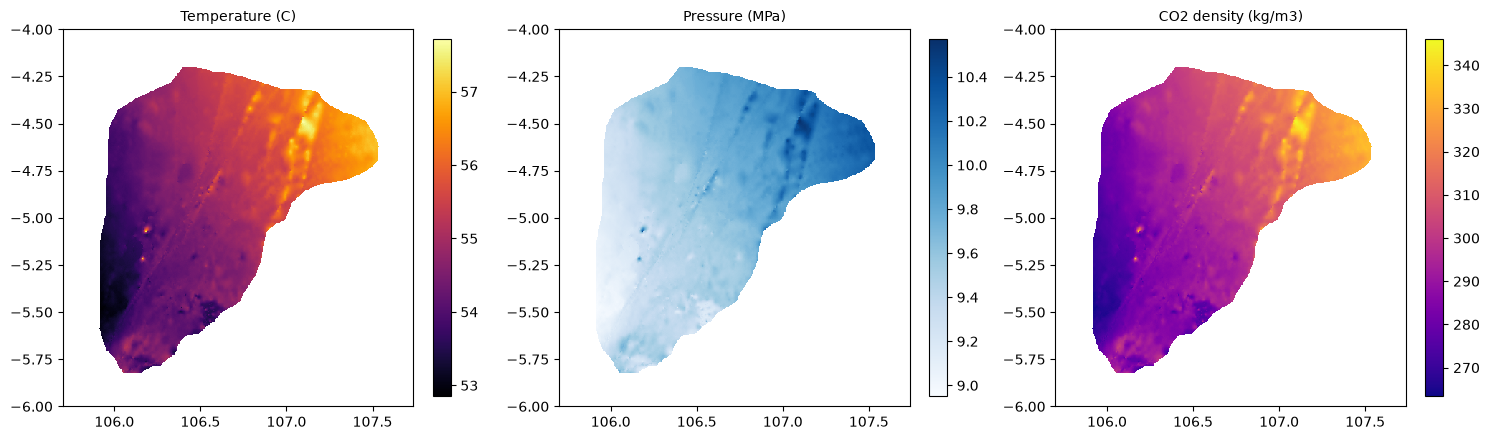

In [4]:

therm = cfg["thermodynamics"]

temperature_c = temperature_from_depth(
    depth_m_masked, geothermal_gradient_c_per_km=therm["geothermal_gradient_C_per_km_default"],
    seabed_temperature_c=therm["seabed_temperature_C"],
)
# Simplification for Tier 2 prototype: hydrostatic conditions assumed everywhere
# (no mapped overpressure zones yet for Sunda-Asri) - see docs/methodology.md.
is_overpressured = np.zeros_like(depth_m_masked, dtype=bool)
pressure_mpa = pressure_from_depth(
    depth_m_masked, is_overpressured,
    hydrostatic_gradient_mpa_per_km=therm["hydrostatic_gradient_MPa_per_km"],
    overpressure_gradient_mpa_per_km=therm["overpressure_gradient_MPa_per_km"],
)

density_kgm3 = co2_density_kgm3(temperature_c, pressure_mpa)
phase = co2_phase(temperature_c, pressure_mpa)

valid = ~np.isnan(depth_m_masked)
print(f"Temperature range: {np.nanmin(temperature_c):.1f} - {np.nanmax(temperature_c):.1f} C")
print(f"Pressure range   : {np.nanmin(pressure_mpa):.1f} - {np.nanmax(pressure_mpa):.1f} MPa")
print(f"CO2 density range: {np.nanmin(density_kgm3):.1f} - {np.nanmax(density_kgm3):.1f} kg/m3")
print(f"Supercritical fraction of valid cells: {(phase[valid] == 'supercritical').mean() * 100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, data, title, cmap in zip(
    axes, [temperature_c, pressure_mpa, density_kgm3],
    ["Temperature (C)", "Pressure (MPa)", "CO2 density (kg/m3)"], ["inferno", "Blues", "plasma"],
):
    im = ax.pcolormesh(lon_mesh, lat_mesh, data, cmap=cmap, shading="auto")
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.savefig(REPO_ROOT / "figures" / "tier2_02_thermophysics.png", dpi=150)
plt.show()


## 3. Porosity-depth trend

Exponential decay trend (Sclater & Christie, 1980 form, same as [MB] §4.3),
parameters from `config.yaml` §`tier2_reservoir_proxy` — PLACEHOLDER until
local core/log-derived porosity data is available for Sunda-Asri.


Porosity range inside basin: 31.1% - 32.9%


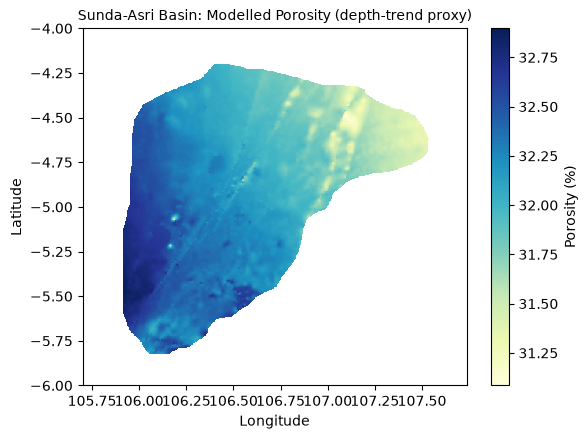

In [5]:

rp = cfg["tier2_reservoir_proxy"]
porosity_fraction = rp["porosity_surface_fraction"] * np.exp(
    -rp["porosity_depth_decay_per_km"] * (depth_m_masked / 1000.0)
)
porosity_percent = porosity_fraction * 100

print(f"Porosity range inside basin: {np.nanmin(porosity_percent):.1f}% - {np.nanmax(porosity_percent):.1f}%")

plt.figure(figsize=(6, 4.5))
plt.pcolormesh(lon_mesh, lat_mesh, porosity_percent, cmap="YlGnBu", shading="auto")
plt.colorbar(label="Porosity (%)")
plt.title("Sunda-Asri Basin: Modelled Porosity (depth-trend proxy)", fontsize=10)
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig(REPO_ROOT / "figures" / "tier2_03_porosity.png", dpi=150)
plt.show()


## 4. Distance to nearest fault

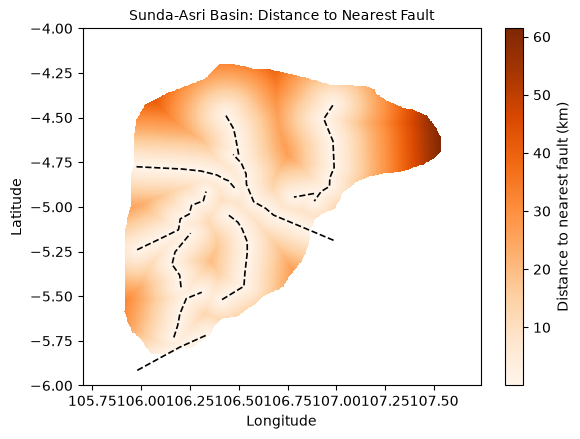

In [6]:

fault_distance_km = distance_to_nearest_fault_km(lon_mesh, lat_mesh, df_faults)
fault_distance_km = np.where(valid, fault_distance_km, np.nan)

plt.figure(figsize=(6, 4.5))
plt.pcolormesh(lon_mesh, lat_mesh, fault_distance_km, cmap="Oranges", shading="auto")
plt.colorbar(label="Distance to nearest fault (km)")
for fid, grp in df_faults.groupby("fault_id"):
    plt.plot(grp["lon"], grp["lat"], "k--", lw=1.2)
plt.title("Sunda-Asri Basin: Distance to Nearest Fault", fontsize=10)
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig(REPO_ROOT / "figures" / "tier2_04_fault_distance.png", dpi=150)
plt.show()


## 5. Triple cut-off screening (porosity + CO2 density + fault distance)

All three criteria from [MB] §4.5.1 applied together — this is the main
methodological gap fixed versus the previous version, which only applied
the CO2 density cut-off.


Optimal    : 32799 cells (36.6% of basin)
Sub-optimal: 54682 cells (61.0% of basin)
Non-viable : 2153 cells


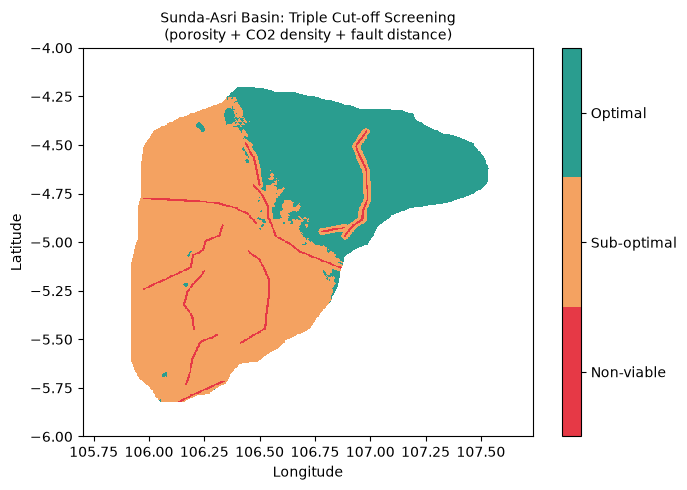

In [7]:

sc = cfg["screening_cutoffs"]

is_optimal = (
    (porosity_percent >= sc["optimal"]["porosity_min_percent"])
    & (density_kgm3 >= sc["optimal"]["co2_density_min_kgm3"])
    & (fault_distance_km >= sc["optimal"]["fault_buffer_km"])
)
is_sub_optimal = (
    (~is_optimal)
    & (porosity_percent >= sc["sub_optimal"]["porosity_min_percent"])
    & (density_kgm3 >= sc["sub_optimal"]["co2_density_min_kgm3"])
    & (fault_distance_km >= sc["sub_optimal"]["fault_buffer_km"])
)

screening_class = np.zeros(depth_m_masked.shape)  # 0 = non-viable
screening_class[is_sub_optimal] = 1
screening_class[is_optimal] = 2
screening_class = np.where(valid, screening_class, np.nan)

n_valid = valid.sum()
n_optimal = int(np.nansum(screening_class == 2))
n_suboptimal = int(np.nansum(screening_class == 1))
print(f"Optimal    : {n_optimal} cells ({n_optimal / n_valid * 100:.1f}% of basin)")
print(f"Sub-optimal: {n_suboptimal} cells ({n_suboptimal / n_valid * 100:.1f}% of basin)")
print(f"Non-viable : {n_valid - n_optimal - n_suboptimal} cells")

cmap_zones = mcolors.ListedColormap(["#e63946", "#f4a261", "#2a9d8f"])
plt.figure(figsize=(7, 5))
plot = plt.pcolormesh(lon_mesh, lat_mesh, screening_class, cmap=cmap_zones, vmin=-0.5, vmax=2.5, shading="auto")
cbar = plt.colorbar(plot, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["Non-viable", "Sub-optimal", "Optimal"])
plt.title("Sunda-Asri Basin: Triple Cut-off Screening\n(porosity + CO2 density + fault distance)", fontsize=10)
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig(REPO_ROOT / "figures" / "tier2_05_screening_classification.png", dpi=150)
plt.show()


## 6. DBSCAN clustering + minimum connected-area filter

Both `eps_raster_pixels` and `min_connected_area_km2` are read from
`config.yaml` — previously `eps` was hardcoded inline (silently
overriding the config value) and the area filter was missing entirely.


DBSCAN found 16 raw clusters (eps=2 pixels, min_samples=5); 1 pass the 100 km2 minimum-area cut-off.
  cluster 4: 6888.0 km2 -> OK
  cluster 1: 44.5 km2 -> discarded (too small)
  cluster 15: 15.6 km2 -> discarded (too small)
  cluster 0: 6.2 km2 -> discarded (too small)
  cluster 10: 6.0 km2 -> discarded (too small)
  cluster 2: 3.6 km2 -> discarded (too small)
  cluster 13: 3.6 km2 -> discarded (too small)
  cluster 12: 3.4 km2 -> discarded (too small)
  cluster 5: 3.2 km2 -> discarded (too small)
  cluster 3: 2.3 km2 -> discarded (too small)
  cluster 6: 1.9 km2 -> discarded (too small)
  cluster 11: 1.7 km2 -> discarded (too small)
  cluster 14: 1.7 km2 -> discarded (too small)
  cluster 8: 1.5 km2 -> discarded (too small)
  cluster 7: 1.1 km2 -> discarded (too small)
  cluster 9: 1.1 km2 -> discarded (too small)


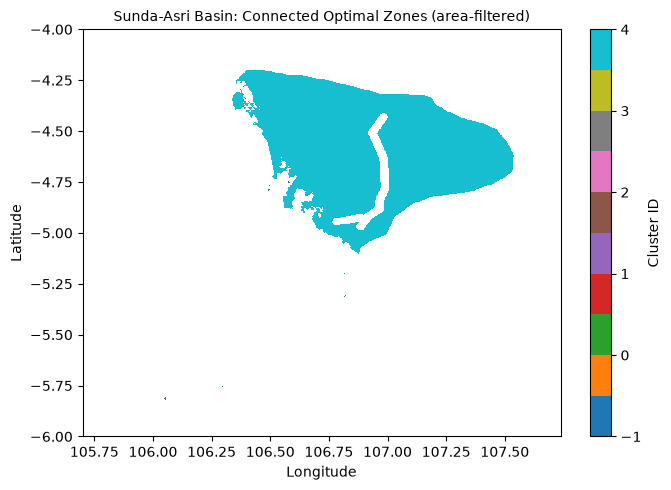

In [8]:

from sklearn.cluster import DBSCAN

optimal_indices = np.argwhere(screening_class == 2)

if len(optimal_indices) == 0:
    print("No optimal cells found - cannot cluster. Try relaxing cut-offs in config.yaml.")
    cluster_grid = np.full(screening_class.shape, np.nan)
    valid_cluster_ids = []
else:
    eps = cfg["clustering"]["eps_raster_pixels"]
    min_samples = cfg["clustering"]["min_samples"]
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(optimal_indices)

    # Approximate cell area (km2) at this latitude, for the area cut-off
    dlat = abs(grid_lat[1] - grid_lat[0])
    dlon = abs(grid_lon[1] - grid_lon[0])
    mean_lat = np.nanmean(lat_mesh)
    cell_area_km2 = (dlat * 111.0) * (dlon * 111.0 * np.cos(np.radians(mean_lat)))

    cluster_grid = np.full(screening_class.shape, np.nan)
    for (row, col), label in zip(optimal_indices, labels):
        cluster_grid[row, col] = label

    cluster_sizes_km2 = {
        lbl: int((labels == lbl).sum()) * cell_area_km2 for lbl in set(labels) if lbl != -1
    }
    min_area = cfg["screening_cutoffs"]["min_connected_area_km2"]
    valid_cluster_ids = [lbl for lbl, area in cluster_sizes_km2.items() if area >= min_area]

    # Drop clusters that are noise (-1) or below the minimum connected area
    for lbl, area in cluster_sizes_km2.items():
        if lbl not in valid_cluster_ids:
            cluster_grid[cluster_grid == lbl] = np.nan

    print(f"DBSCAN found {len(cluster_sizes_km2)} raw clusters "
          f"(eps={eps} pixels, min_samples={min_samples}); "
          f"{len(valid_cluster_ids)} pass the {min_area} km2 minimum-area cut-off.")
    for lbl in sorted(cluster_sizes_km2, key=cluster_sizes_km2.get, reverse=True):
        flag = "OK" if lbl in valid_cluster_ids else "discarded (too small)"
        print(f"  cluster {int(lbl)}: {cluster_sizes_km2[lbl]:.1f} km2 -> {flag}")

plt.figure(figsize=(7, 5))
plt.pcolormesh(lon_mesh, lat_mesh, cluster_grid, cmap="tab10", shading="auto")
plt.colorbar(label="Cluster ID")
plt.title("Sunda-Asri Basin: Connected Optimal Zones (area-filtered)", fontsize=10)
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig(REPO_ROOT / "figures" / "tier2_06_clusters.png", dpi=150)
plt.show()


## 7. Monte Carlo volumetric capacity per cluster

Calls **`montecarlo_capacity.monte_carlo_capacity()`** directly (the tested
module), instead of reimplementing the Goodman et al. (2011) equation
inline. Thickness and NTG distributions come from `config.yaml`
§`tier2_reservoir_proxy`; porosity and CO2 density use the *actual modelled
mean* within each cluster (not a flat assumption).


In [9]:

ce = cfg["capacity_equation"]
rp = cfg["tier2_reservoir_proxy"]

results = []
for cluster_id in valid_cluster_ids:
    mask = cluster_grid == cluster_id
    n_cells = int(np.nansum(mask))
    area_km2 = n_cells * cell_area_km2
    mean_porosity = float(np.nanmean(np.where(mask, porosity_fraction, np.nan)))
    mean_density = float(np.nanmean(np.where(mask, density_kgm3, np.nan)))

    mc = monte_carlo_capacity(
        area_km2=area_km2,
        thickness_m=NormalParam(mean=rp["thickness_m_mean"], std=rp["thickness_m_std"], lower_bound=0),
        ntg_fraction=NormalParam(mean=rp["ntg_mean"], std=rp["ntg_std"], lower_bound=0, upper_bound=1),
        porosity_fraction=NormalParam(mean=mean_porosity, std=mean_porosity * 0.15, lower_bound=0, upper_bound=1),
        swirr_fraction=NormalParam(mean=ce["swirr_mean"], std=ce["swirr_std"], lower_bound=0, upper_bound=1),
        efficiency_fraction=NormalParam(
            mean=ce["efficiency_factor_percent_mean"] / 100, std=ce["efficiency_factor_percent_std"] / 100,
            lower_bound=0, upper_bound=1,
        ),
        co2_density_kgm3=NormalParam(mean=mean_density, std=mean_density * 0.1, lower_bound=0),
        n_iterations=ce["monte_carlo_iterations"],
        random_seed=42 + int(cluster_id),
    )
    stats = summarize_capacity(mc)
    stats.update(dict(cluster_id=int(cluster_id), area_km2=area_km2,
                       mean_porosity_pct=mean_porosity * 100, mean_co2_density=mean_density))
    results.append(stats)

df_results = pd.DataFrame(results)
if not df_results.empty:
    df_results = df_results[["cluster_id", "area_km2", "mean_porosity_pct", "mean_co2_density",
                              "P10_Gt", "P50_Gt", "P90_Gt"]].sort_values("P50_Gt", ascending=False)
    print(df_results.round(3).to_string(index=False))
else:
    print("No valid clusters to run Monte Carlo capacity on.")


 cluster_id  area_km2  mean_porosity_pct  mean_co2_density  P10_Gt  P50_Gt  P90_Gt
          4  6887.995              31.77           314.014    0.53   0.248   0.098


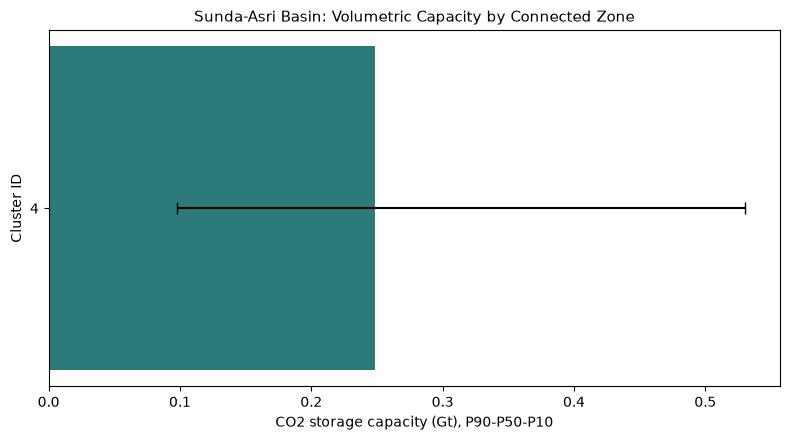

Results exported to data\processed\sunda_asri_capacity_results.csv


In [12]:

if not df_results.empty:
    plt.figure(figsize=(8, 4.5))
    plt.barh(df_results["cluster_id"].astype(str), df_results["P50_Gt"], color="#2b7b7b")
    plt.errorbar(
        df_results["P50_Gt"], df_results["cluster_id"].astype(str),
        xerr=[df_results["P50_Gt"] - df_results["P90_Gt"], df_results["P10_Gt"] - df_results["P50_Gt"]],
        fmt="none", ecolor="black", capsize=4,
    )
    plt.xlabel("CO2 storage capacity (Gt), P90-P50-P10")
    plt.ylabel("Cluster ID")
    plt.title("Sunda-Asri Basin: Volumetric Capacity by Connected Zone", fontsize=11)
    plt.tight_layout()
    plt.savefig(REPO_ROOT / "figures" / "tier2_07_capacity_by_cluster.png", dpi=150)
    plt.show()

    output_path = REPO_ROOT / "data" / "processed" / "sunda_asri_capacity_results.csv"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df_results.to_csv(output_path, index=False)
    print(f"Results exported to {output_path.relative_to(REPO_ROOT)}")


## 8. Summary & limitations

**Fixed in this version (vs. the previous notebook):**
- Always runs end-to-end, even with zero real data present (synthetic
  depth surface + illustrative boundary/faults as fallback, loudly labelled).
- CO2 density computed from the actual CoolProp-based `co2_thermophysics.py`
  module, not an empirical linear formula.
- All three [MB] cut-off criteria applied (porosity, CO2 density, fault
  distance) instead of just one.
- DBSCAN clusters filtered by `min_connected_area_km2` from `config.yaml`.
- Reservoir parameters (thickness, NTG, porosity trend) and DBSCAN `eps`
  moved to `config.yaml` §`tier2_reservoir_proxy` / §`clustering`.
- Reuses `montecarlo_capacity.py` and `optimal_zone_screening.py` directly
  instead of reimplementing their logic inline.

**Still open (honest limitations — see `docs/methodology.md` §4):**
- Basin boundary and fault traces are illustrative unless you have supplied
  real digitized files — check the printed data source in Section 1.
- Porosity-depth trend and NTG/thickness are generic proxies, not
  calibrated to local well/core data.
- No mapped overpressure zones for Sunda-Asri yet (hydrostatic assumed
  everywhere).
